In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/country_wise_latest.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/day_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/usa_county_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/full_grouped.csv


In [2]:
import pandas as pd
df= pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv')
df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [3]:
import pandas as pd
df= pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/usa_county_wise.csv')
df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0


In [4]:
print(df.columns)

Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Date', 'Confirmed',
       'Deaths'],
      dtype='object')


In [5]:
california = df[df['Province_State'] == 'California']
california.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
268,84006001,US,USA,840,6001.0,Alameda,California,US,37.646294,-121.892927,"Alameda, California, US",1/22/20,0,0
269,84006003,US,USA,840,6003.0,Alpine,California,US,38.596786,-119.822359,"Alpine, California, US",1/22/20,0,0
270,84006005,US,USA,840,6005.0,Amador,California,US,38.445831,-120.656960,"Amador, California, US",1/22/20,0,0
271,84006007,US,USA,840,6007.0,Butte,California,US,39.667278,-121.600525,"Butte, California, US",1/22/20,0,0
272,84006009,US,USA,840,6009.0,Calaveras,California,US,38.205371,-120.552913,"Calaveras, California, US",1/22/20,0,0


In [6]:
specific_county = df[df['Admin2'] == 'Los Angeles']
specific_county.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
286,84006037,US,USA,840,6037.0,Los Angeles,California,US,34.308284,-118.228241,"Los Angeles, California, US",1/22/20,0,0
3626,84006037,US,USA,840,6037.0,Los Angeles,California,US,34.308284,-118.228241,"Los Angeles, California, US",1/23/20,0,0
6966,84006037,US,USA,840,6037.0,Los Angeles,California,US,34.308284,-118.228241,"Los Angeles, California, US",1/24/20,0,0
10306,84006037,US,USA,840,6037.0,Los Angeles,California,US,34.308284,-118.228241,"Los Angeles, California, US",1/25/20,0,0
13646,84006037,US,USA,840,6037.0,Los Angeles,California,US,34.308284,-118.228241,"Los Angeles, California, US",1/26/20,1,0


In [7]:
us_daily = df.groupby('Date')[['Confirmed', 'Deaths']].sum()
us_daily.tail(10)

,Confirmed,Deaths
Date,,
7/25/20,4178970,146465
7/26/20,4233923,146935
7/27/20,4290259,148011
7/3/20,2795361,129442
7/4/20,2841241,129689
7/5/20,2891124,129960
7/6/20,2936077,130285
7/7/20,2996098,131480
7/8/20,3054699,132300


In [8]:
df.info

<bound method DataFrame.info of              UID iso2 iso3  code3     FIPS          Admin2  \
0             16   AS  ASM     16     60.0             NaN   
1            316   GU  GUM    316     66.0             NaN   
2            580   MP  MNP    580     69.0             NaN   
3       63072001   PR  PRI    630  72001.0        Adjuntas   
4       63072003   PR  PRI    630  72003.0          Aguada   
...          ...  ...  ...    ...      ...             ...   
627915  84070016   US  USA    840      NaN    Central Utah   
627916  84070017   US  USA    840      NaN  Southeast Utah   
627917  84070018   US  USA    840      NaN  Southwest Utah   
627918  84070019   US  USA    840      NaN       TriCounty   
627919  84070020   US  USA    840      NaN    Weber-Morgan   

                  Province_State Country_Region        Lat       Long_  \
0                 American Samoa             US -14.271000 -170.132000   
1                           Guam             US  13.444300  144.793700   
2

In [9]:
df.isnull().sum()

UID                  0
iso2                 0
iso3                 0
code3                0
FIPS              1880
Admin2            1128
Province_State       0
Country_Region       0
Lat                  0
Long_                0
Combined_Key         0
Date                 0
Confirmed            0
Deaths               0
dtype: int64

In [10]:
df.describe()

,UID,code3,FIPS,Lat,Long_,Confirmed,Deaths
count,6.279200e+05,627920.000000,626040.000000,627920.000000,627920.000000,627920.000000,627920.000000
mean,8.342958e+07,834.491617,33061.684685,36.707212,-88.601474,357.284285,17.536328
std,4.314702e+06,36.492620,18636.156825,9.061572,21.715747,3487.282694,300.991466
min,1.600000e+01,16.000000,60.000000,-14.271000,-174.159600,0.000000,0.000000
25%,8.401811e+07,840.000000,19079.000000,33.895587,-97.790204,0.000000,0.000000
50%,8.402921e+07,840.000000,31014.000000,38.002344,-89.486710,4.000000,0.000000
75%,8.404612e+07,840.000000,47131.000000,41.573069,-82.311265,63.000000,1.000000
max,8.410000e+07,850.000000,99999.000000,69.314792,145.673900,224051.000000,23500.000000


In [11]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [12]:
print(df.columns)

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')


In [13]:
south_africa = df[df['Country/Region'] == 'South Africa']
south_africa.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
198,NaN,South Africa,-30.5595,22.9375,2020-01-22,0,0,0,0,Africa
459,NaN,South Africa,-30.5595,22.9375,2020-01-23,0,0,0,0,Africa
720,NaN,South Africa,-30.5595,22.9375,2020-01-24,0,0,0,0,Africa
981,NaN,South Africa,-30.5595,22.9375,2020-01-25,0,0,0,0,Africa
1242,NaN,South Africa,-30.5595,22.9375,2020-01-26,0,0,0,0,Africa


<Axes: title={'center': 'South Africa Confirmed Cases Over Time'}, xlabel='Date'>

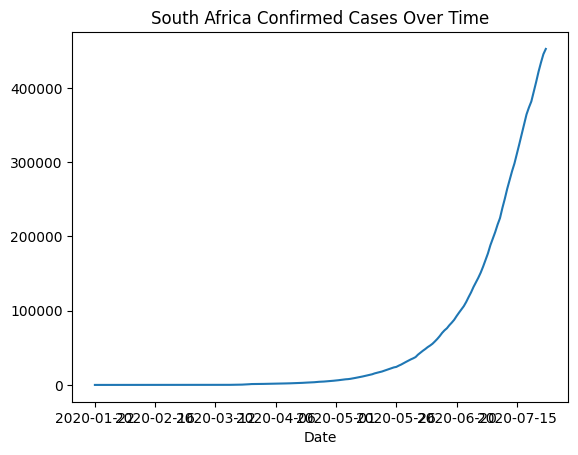

In [14]:
south_africa.groupby('Date')['Confirmed'].sum().plot(title='South Africa Confirmed Cases Over Time')